## Machine Failure Prediction

## Objective:
    The goal of this project is to predict machine failures based on sensor readings and operational settings.
    Predicting potential failures in advance helps reduce maintenance costs, downtime, and improves overall production efficiency.


In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
filterwarnings('ignore')

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
url = "https://raw.githubusercontent.com/ashwini-ah18/machin-larning-datasets/refs/heads/main/Classification%20Train%20dataset.csv"
df = pd.read_csv(url)

In [4]:
# Basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (136429, 14)

Columns:
 Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

Data Types:
 id                           int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [5]:
# Preview
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


### Identify Target & Features

In [6]:
target = 'Machine failure'   # adjust if name differs
features = df.drop(columns=[target]).columns

print("Target:", target)
print("Features:", list(features))

Target: Machine failure
Features: ['id', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


### Check Class Imbalance

Machine failure
0    134281
1      2148
Name: count, dtype: int64


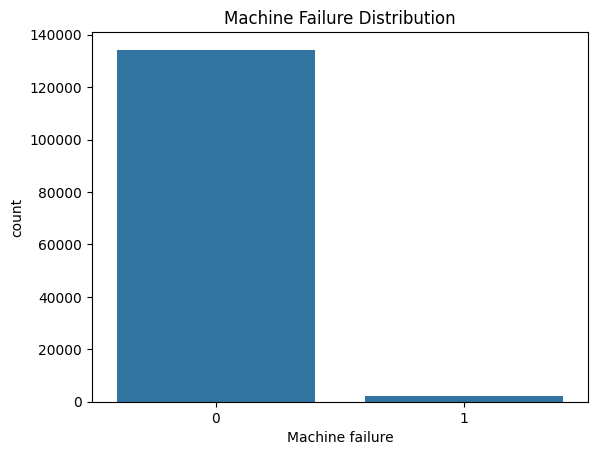

In [7]:
print(df[target].value_counts())

sns.countplot(x=df[target])
plt.title("Machine Failure Distribution")
plt.show()

## 2. Data Cleaning

In [8]:
# Missing values
print(df.isnull().sum())

# Drop duplicates
df = df.drop_duplicates()

# Ensure correct datatypes
df.info()

id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  str    
 2   Type                     136429 non-null  str    
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-

### Handle Categorical Column (Type)

In [9]:
print(df['Type'].value_counts())

Type
L    95354
M    32152
H     8923
Name: count, dtype: int64


### 📊 3. Exploratory Data Analysis (EDA)
### 📈 Distribution of Features

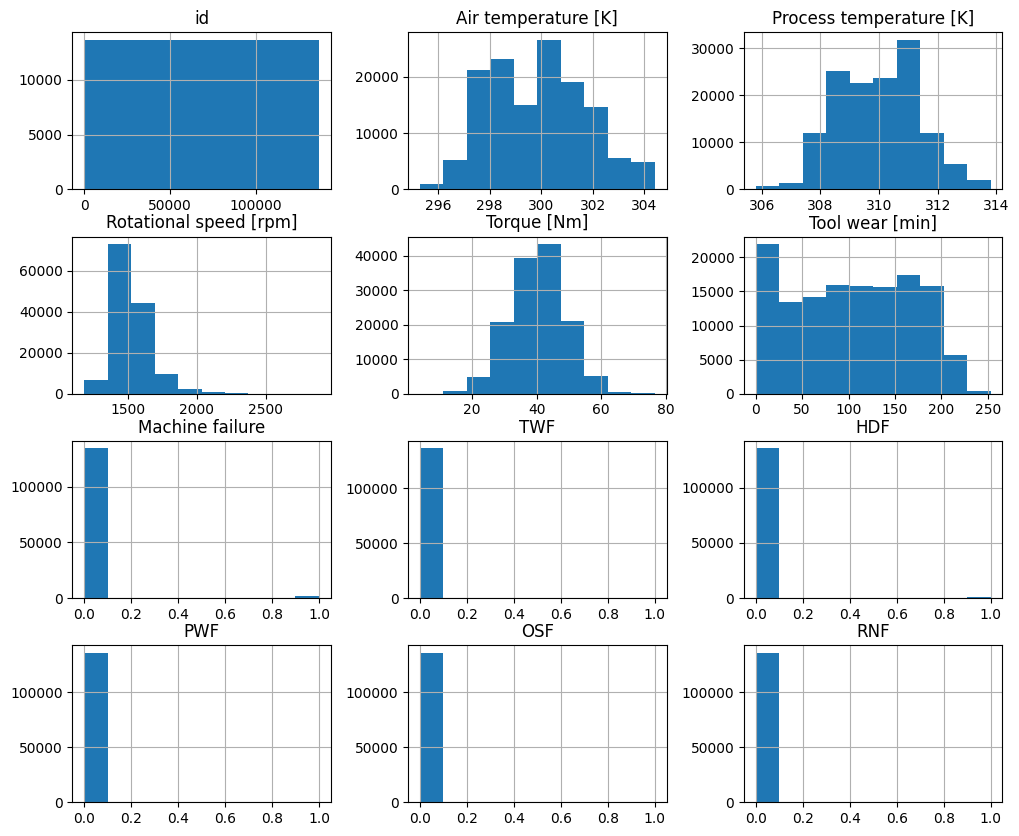

In [10]:
df.hist(figsize=(12,10))
plt.show()

### 📦 Boxplots (Failure vs Features)

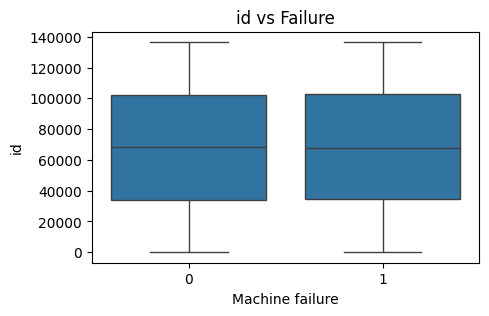

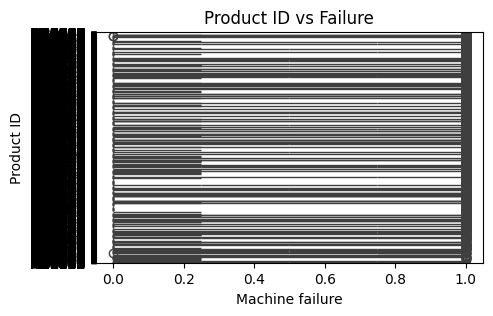

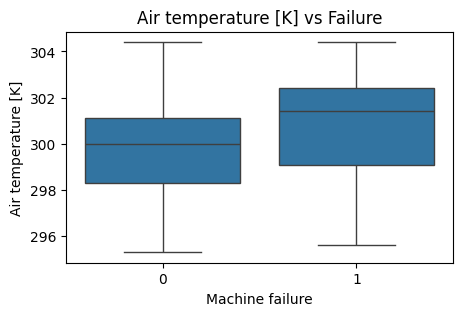

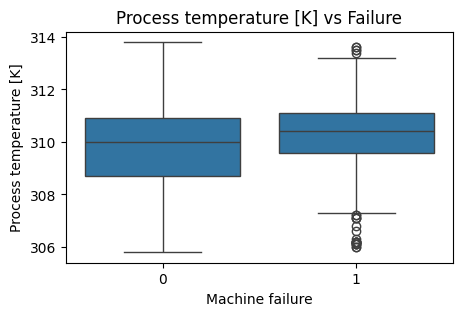

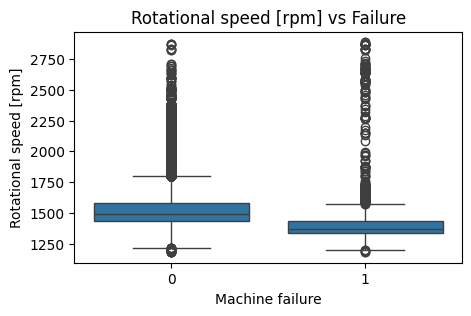

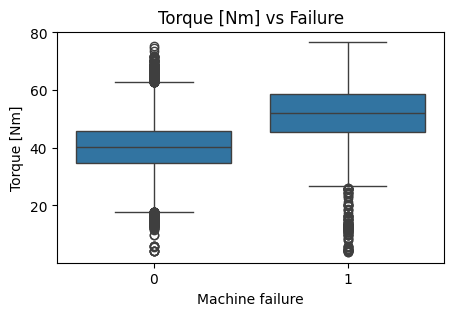

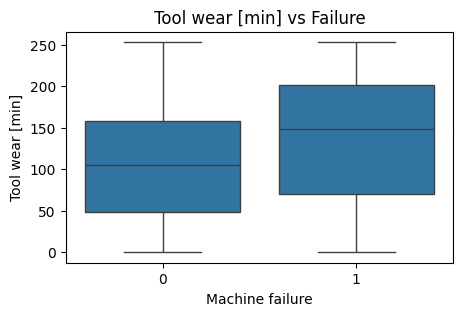

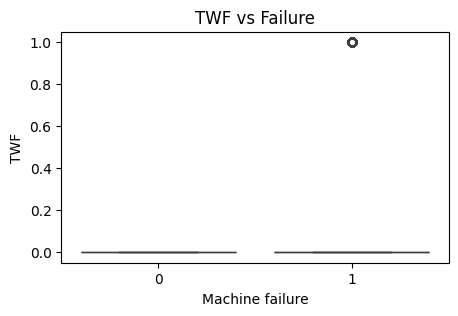

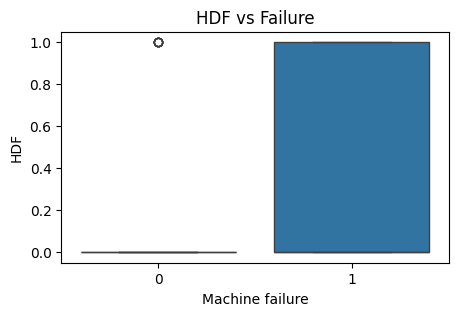

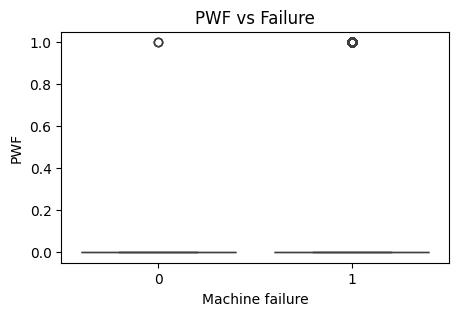

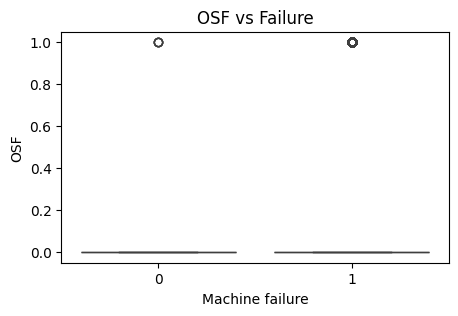

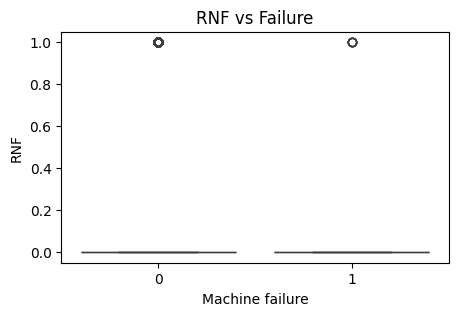

In [11]:
for col in features:
    if col != 'Type':
        plt.figure(figsize=(5,3))
        sns.boxplot(x=df[target], y=df[col])
        plt.title(f"{col} vs Failure")
        plt.show()

### 🔥 Correlation Heatmap

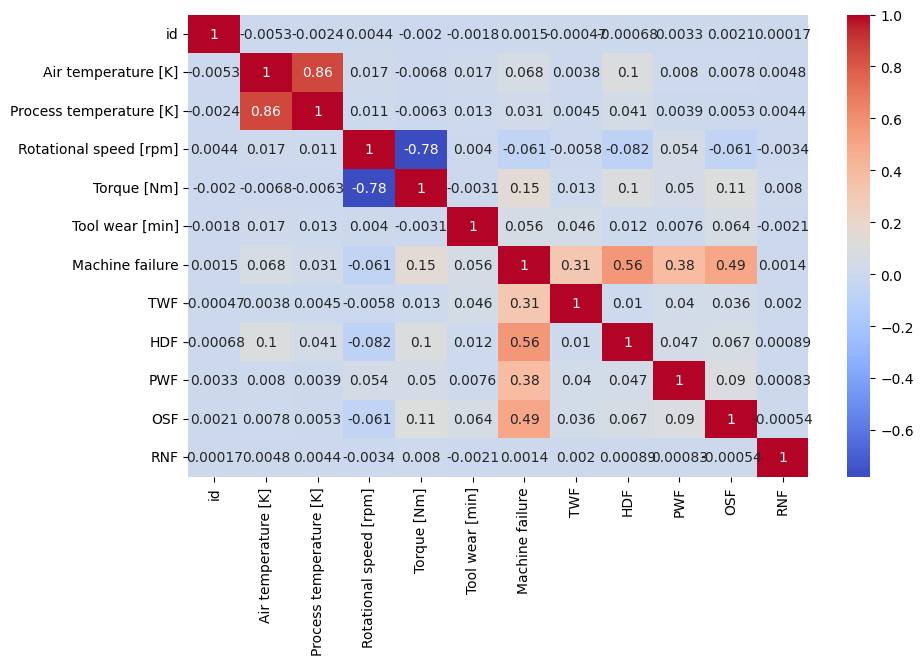

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

### 🔍 Pairplot

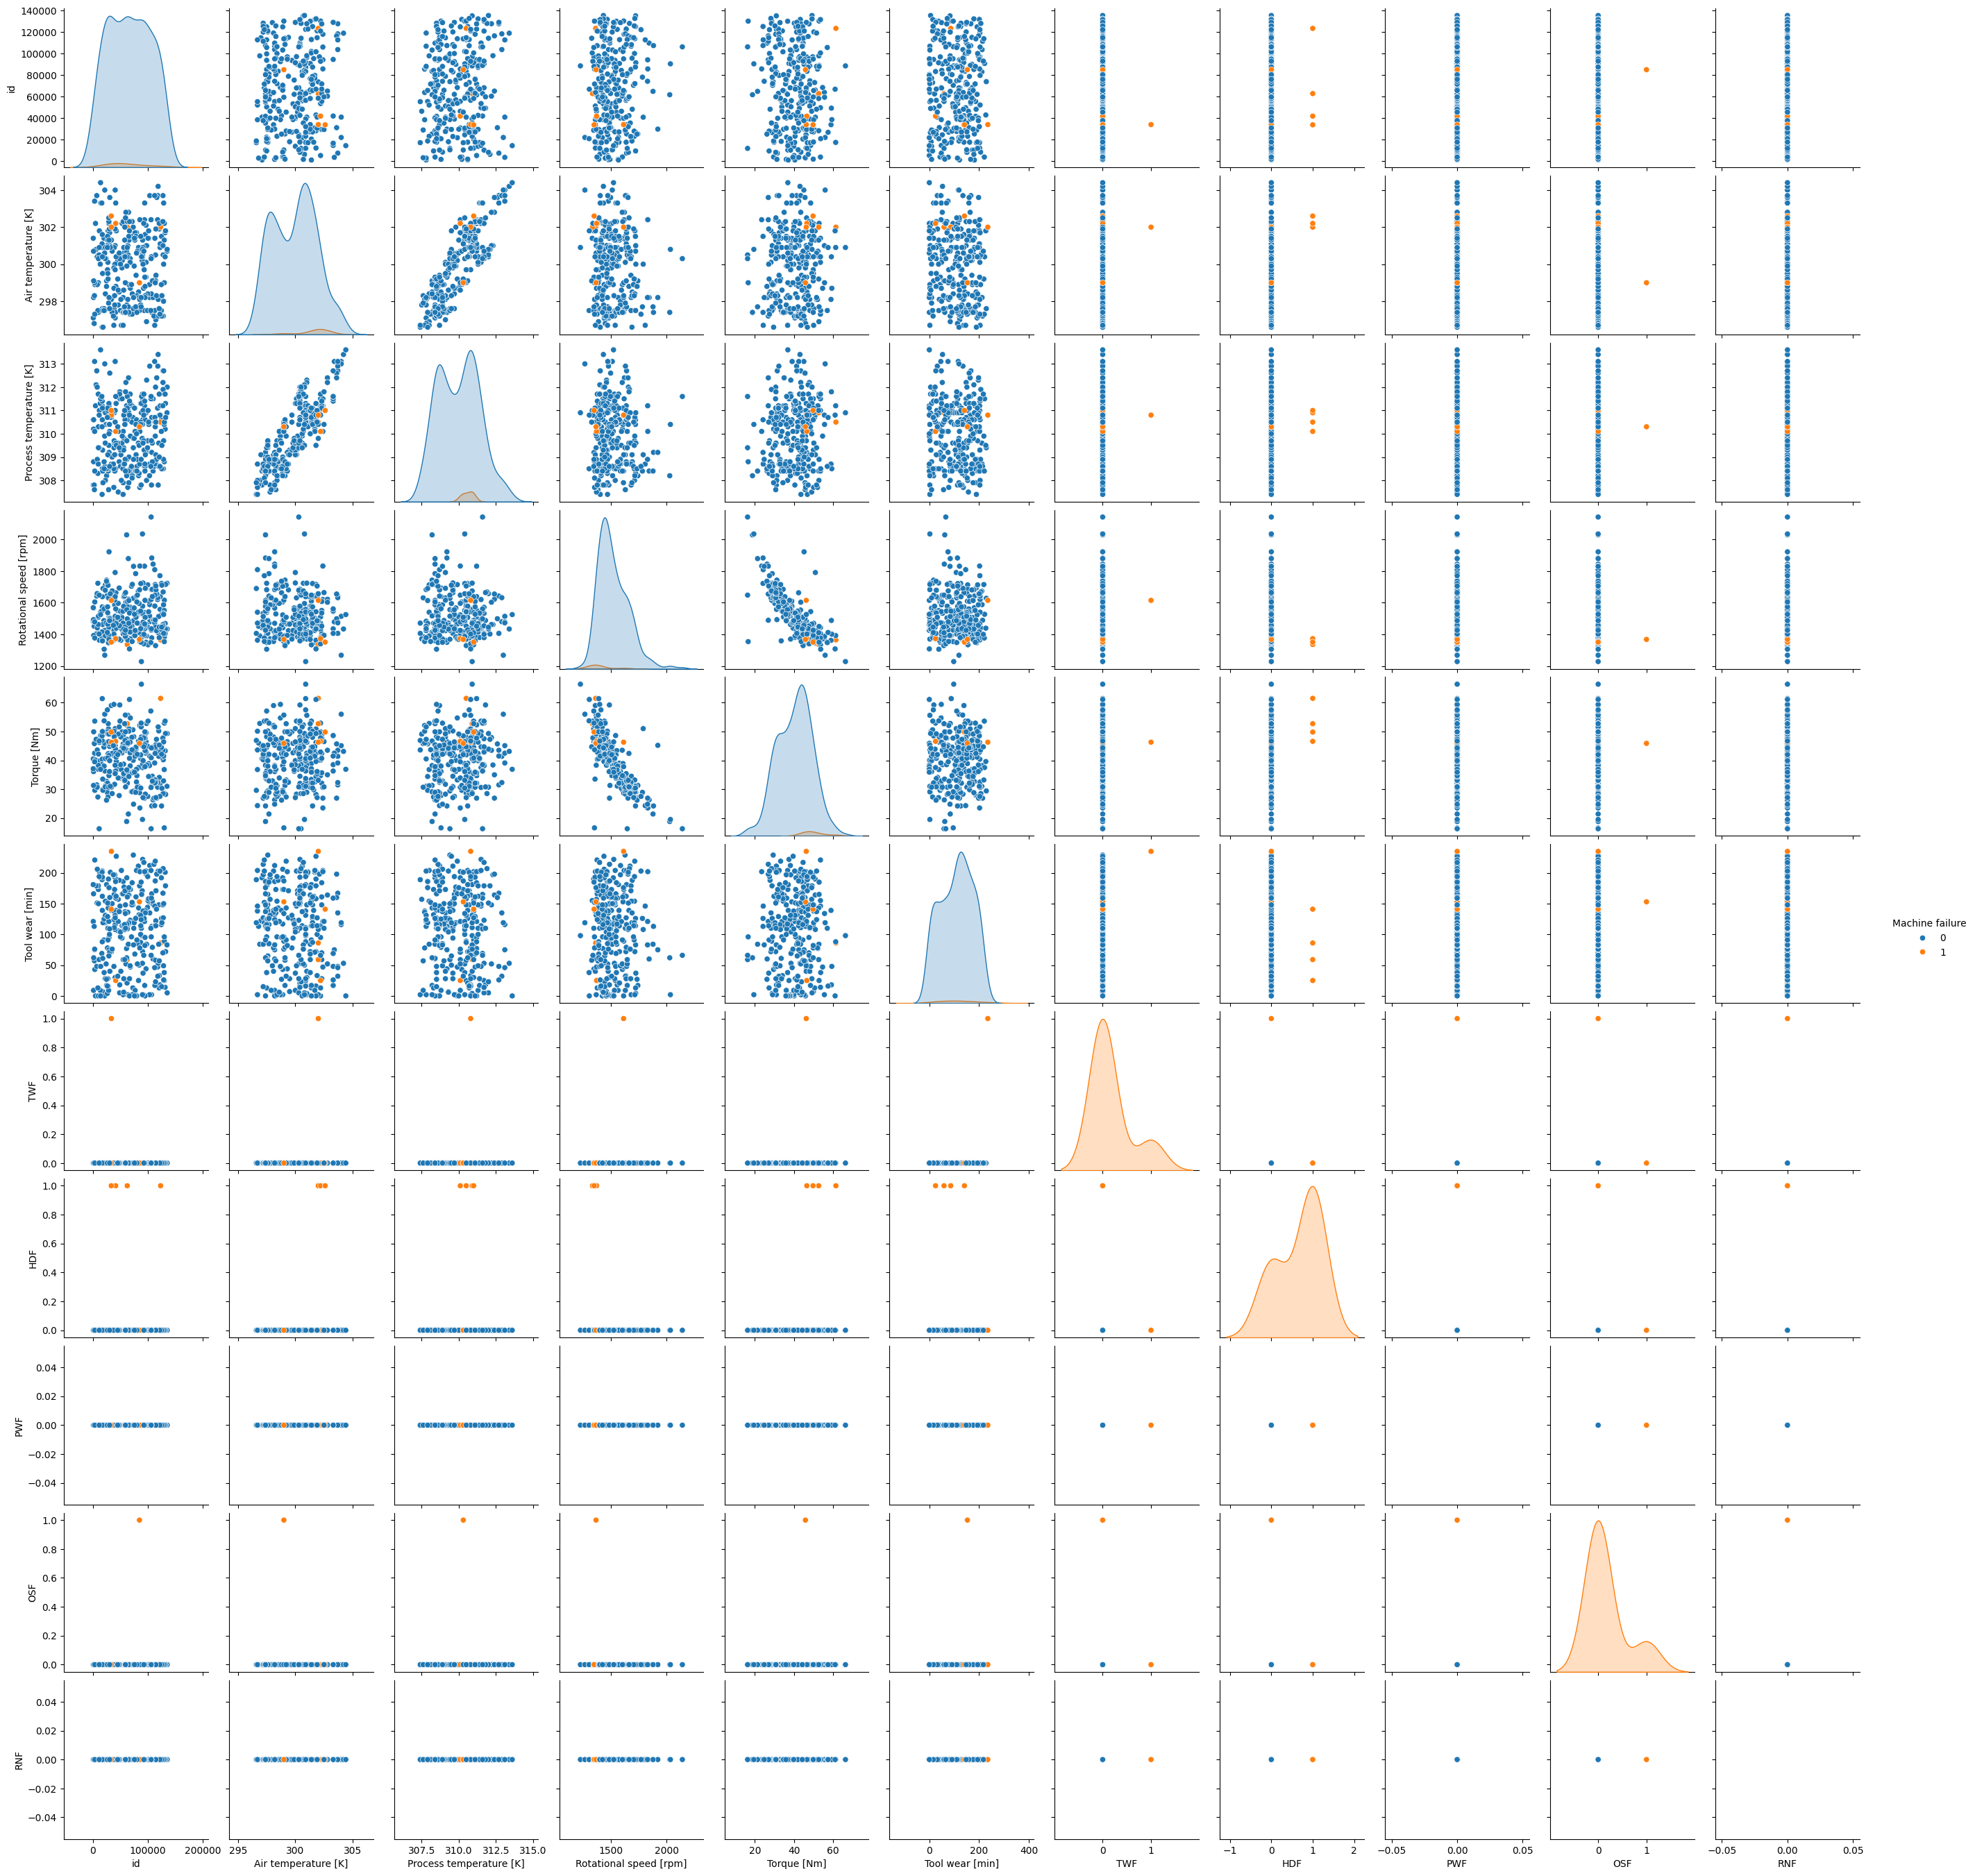

In [13]:
sns.pairplot(df.sample(300), hue=target)  # sample to avoid lag
plt.show()

## ⚙️ 4. Feature Engineering
## 🔤 Encode Categorical Feature

In [14]:
import pandas as pd
import numpy as np

# Load dataset
url = "https://raw.githubusercontent.com/ashwini-ah18/machin-larning-datasets/refs/heads/main/Classification%20Train%20dataset.csv"
df = pd.read_csv(url)

# Preview
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [15]:
from sklearn.preprocessing import OneHotEncoder

# Check column name (important)
print(df.columns)

# OneHot Encoding
encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded = encoder.fit_transform(df[['Type']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Type']))

# Merge back
df = pd.concat([df.drop(columns=['Type']), encoded_df], axis=1)

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')


In [16]:
# Example feature
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

In [17]:
target = 'Machine failure'   # ⚠️ check exact name in your dataset

X = df.drop(columns=[target])
y = df[target]

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = X.select_dtypes(include=['float64', 'int64']) # Drop strings/objects

### Train-Test Split

In [19]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform your features (assuming your features are in a variable named 'X')
X_scaled = scaler.fit_transform(X)

# Now your split will work
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

NameError: name 'train_test_split' is not defined

In [ ]:
# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[26845     3]
 [  102   336]]


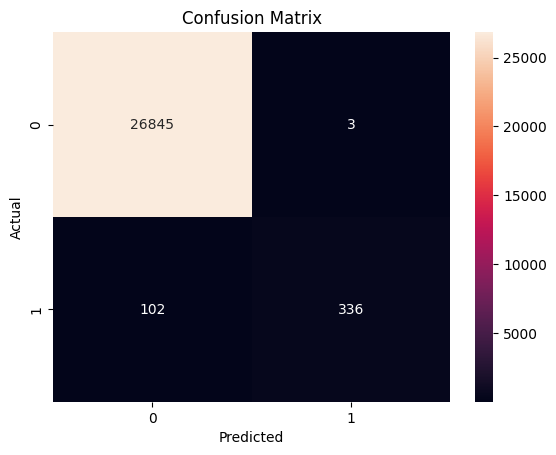

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # <--- ADD THIS LINE

# Visual Confusion Matrix
plt.figure()
# Note: Fixed typo 'annot-True' to 'annot=True'
sns.heatmap(cm, annot=True, fmt='d') 

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show() # Recommended to ensure the plot displays


Logistic Regression Confusion Matrix:
[[26845     3]
 [  102   336]]

Decision Tree Confusion Matrix:
[[26724   124]
 [   94   344]]

Random Forest Confusion Matrix:
[[26842     6]
 [  102   336]]


c:\ml files\repository\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:58:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Confusion Matrix:
[[26840     8]
 [  100   338]]

SVM Confusion Matrix:
[[26845     3]
 [  102   336]]


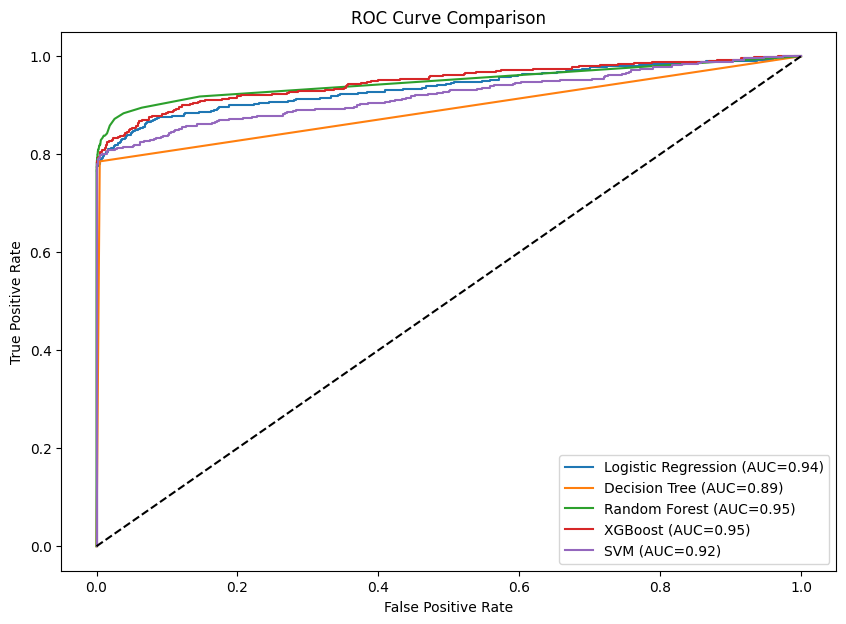


Model Comparison:
                 Model  Accuracy  Precision    Recall  F1-score       AUC
2        Random Forest  0.996042   0.982456  0.767123  0.861538  0.948660
3              XGBoost  0.996042   0.976879  0.771689  0.862245  0.948295
0  Logistic Regression  0.996152   0.991150  0.767123  0.864865  0.936632
4                  SVM  0.996152   0.991150  0.767123  0.864865  0.920318
1        Decision Tree  0.992011   0.735043  0.785388  0.759382  0.890385


In [ ]:
# 4. Define Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC(probability=True)
}

# ===============================
#  Evaluation Function
# ===============================
results = []

plt.figure(figsize=(10, 7))

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, auc])

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

    # Confusion Matrix
    print(f"\n{name} Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

# ===============================
#  ROC Curve Plot
# ===============================
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ===============================
#  Results Table
# ===============================
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score", "AUC"
])

print("\nModel Comparison:")
print(results_df.sort_values(by="AUC", ascending=False))